In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer  # <--- The key difference!
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

In [8]:
# --- STEP 1: Load Data (Teammate-Safe) ---
print("🔄 Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])

🔄 Loading data...


In [9]:
# --- STEP 2: Vectorization (Bag of Words) ---
print("🧮 Vectorizing text using Bag of Words (CountVectorizer)...")

# We use CountVectorizer instead of TfidfVectorizer
# max_features=5000 ensures we keep the model size comparable to the paper
vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(df['posts'])
y = df['type'].values

print(f"✅ Data Ready! Features shape: {X.shape}")

🧮 Vectorizing text using Bag of Words (CountVectorizer)...
✅ Data Ready! Features shape: (8462, 2000)


In [11]:
# --- STEP 3: Train & Evaluate (BoW) ---
print("\n🚀 Starting Naive Bayes (BoW) Training...")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}

for trait1, trait2 in dimensions:
    print(f"\n--- Processing {trait1} vs {trait2} ---")
    
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y_binary)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.20, random_state=42
    )
    
    # Train with alpha for regularization
    clf = MultinomialNB(alpha=5.0)  # Add regularization to prevent overfitting
    clf.fit(X_train, y_train)
    
    # Evaluate on BOTH train and test sets
    train_preds = clf.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    
    test_preds = clf.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    
    conf_mat = confusion_matrix(y_test, test_preds)
    
    results[f"{trait1}/{trait2}"] = test_acc
    
    # Display results with overfitting detection
    print(f"   Train Accuracy: {train_acc:.2%}")
    print(f"   Test Accuracy:  {test_acc:.2%}")
    print(f"   Difference:     {(train_acc - test_acc):.2%}")
    if train_acc - test_acc > 0.05:
        print(f"   ⚠️  Possible overfitting detected!")
    print(f"   Confusion Matrix:\n{conf_mat}")

# --- SUM OF ACCURACIES ---
total_accuracy = sum(results.values())
avg_accuracy = total_accuracy / len(results)
print(f"\n📈 Total Sum of Accuracies: {total_accuracy:.4f}")
print(f"📊 Average Accuracy: {avg_accuracy:.2%}")


🚀 Starting Naive Bayes (BoW) Training...

--- Processing I vs E ---
   Train Accuracy: 73.19%
   Test Accuracy:  71.58%
   Difference:     1.61%
   Confusion Matrix:
[[953 353]
 [390 918]]

--- Processing N vs S ---
   Train Accuracy: 79.67%
   Test Accuracy:  78.79%
   Difference:     0.88%
   Confusion Matrix:
[[1162  324]
 [ 294 1134]]

--- Processing T vs F ---
   Train Accuracy: 77.43%
   Test Accuracy:  77.88%
   Difference:     -0.45%
   Confusion Matrix:
[[700 211]
 [192 719]]

--- Processing J vs P ---
   Train Accuracy: 71.05%
   Test Accuracy:  66.65%
   Difference:     4.40%
   Confusion Matrix:
[[662 354]
 [326 697]]

📈 Total Sum of Accuracies: 2.9490
📊 Average Accuracy: 73.72%



📊 Generating BoW Results Graph...


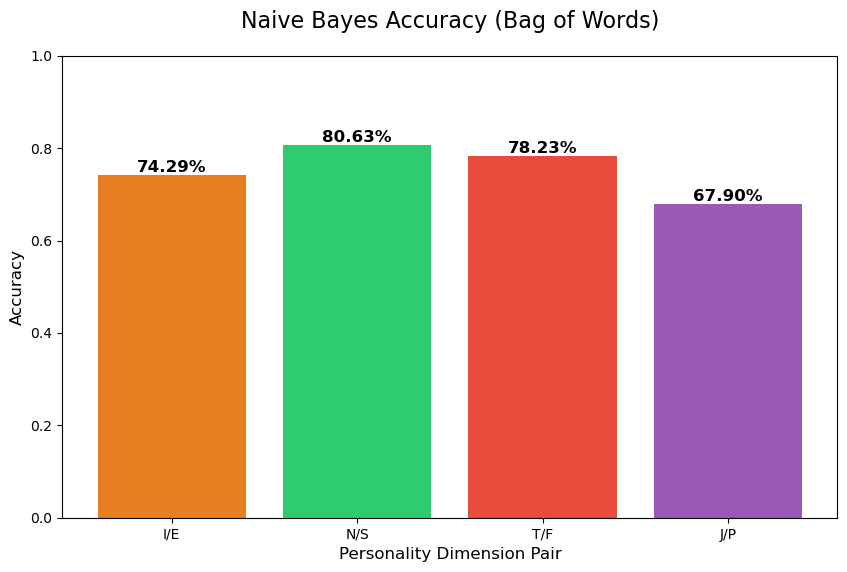

In [6]:
# --- PLOTTING THE RESULTS ---
print("\n📊 Generating BoW Results Graph...")

plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Using a slightly different color palette to distinguish from TF-IDF
bars = plt.bar(keys, values, color=['#e67e22', '#2ecc71', '#e74c3c', '#9b59b6'])

plt.title('Naive Bayes Accuracy (Bag of Words)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0) 

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()